# 📚 Image Recognition and Generation

This notebook showcases **real-world applications** of Convolutional Neural Networks (CNNs), focusing on:

- 🔍 Object Detection using **YOLO + Supervision**
- 🔢 Object Counting (e.g., vehicles)
- 🔥 Heatmap Generation for density analysis
- 📖 Optical Character Recognition (OCR)


CNNs are powerful because they not only classify images but also understand **where** objects are and **how many** exist. These use cases appear in:

- Self-driving cars (object detection, lane detection)
- Retail analytics (customer heatmaps)
- Surveillance (person/vehicle counting)
- Document reading (OCR)


# Requirements:
Install required libraries:


In [ ]:
!pip install supervision ultralytics roboflow pytesseract rfdetr inference

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.3/266.3 kB 11.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached ninja-1.11.1.4-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.0 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 10.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

# SECTION 1: Object Detection with YOLO

In [ ]:
## LOAD OBJECT DETECTION MODEL

import supervision as sv
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load YOLOv8 model
model = YOLO("yolo11x.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 109M/109M [00:00<00:00, 124MB/s] 



0: 384x640 6 persons, 2 ties, 66.8ms
Speed: 3.4ms preprocess, 66.8ms inference, 4.0ms postprocess per image at shape (1, 3, 384, 640)


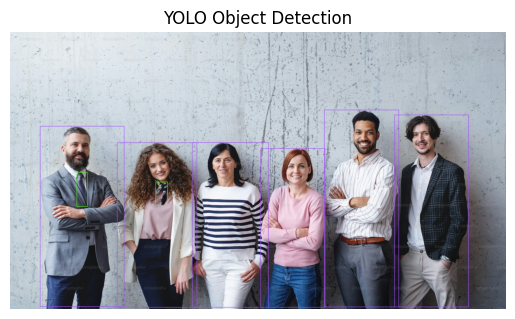

In [ ]:
# Load image
image_path = "/content/object_detect_image.jpg"
image = cv2.imread(image_path)


# Run inference
results = model(image)[0]

# print(results)

# Annotate
box_annotator = sv.BoxAnnotator()
detections = sv.Detections.from_ultralytics(results)
annotated_image = box_annotator.annotate(scene=image.copy(), detections=detections)

# Show
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.title("YOLO Object Detection")
plt.axis(False)
plt.show()


0: 384x640 2 persons, 8 cars, 63.3ms
Speed: 3.7ms preprocess, 63.3ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


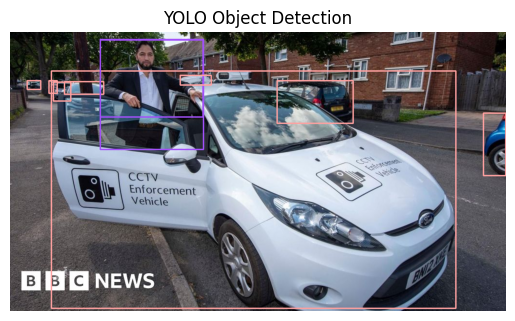

In [ ]:
# Load image
image_path = "/content/Car_image.jpg"
image = cv2.imread(image_path)

# Run inference
results = model(image)[0]

# Annotate
box_annotator = sv.BoxAnnotator()
detections = sv.Detections.from_ultralytics(results)
annotated_image = box_annotator.annotate(scene=image.copy(), detections=detections)

# Show
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.title("YOLO Object Detection")
plt.axis(False)
plt.show()

ModelDependencyMissing: Your `inference` configuration does not support Qwen2.5-VL model. Use pip install 'inference[transformers]' to install missing requirements.To suppress this warning, set QWEN_2_5_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support SAM2 model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM2_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support CLIP model. Use pip install 'inference[clip]' to install missing requirements.To suppress this warning, set CORE_MODEL_CLIP_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support Gaze Detection model. Use pip install 'inference[gaze]' to install mi

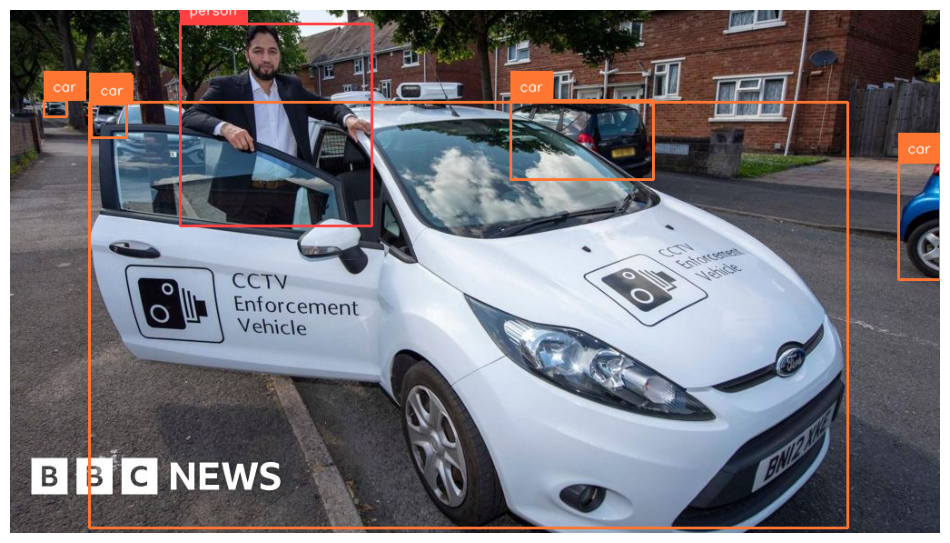

In [ ]:
import os ,io
import supervision as sv
from inference import get_model
from PIL import Image
from io import BytesIO
import requests

url = "https://ichef.bbci.co.uk/news/1024/branded_news/eec8/live/9e228280-50e5-11f0-922f-9fb4bdd79d98.jpg"
image = Image.open(io.BytesIO(requests.get(url).content))

model = get_model("rfdetr-base")

predictions = model.infer(image, confidence=0.5)[0]

detections = sv.Detections.from_inference(predictions)

labels = [prediction.class_name for prediction in predictions.predictions]

annotated_image = image.copy()
annotated_image = sv.BoxAnnotator().annotate(annotated_image, detections)
annotated_image = sv.LabelAnnotator().annotate(annotated_image, detections, labels)

sv.plot_image(annotated_image)

annotated_image.save("annotated_image_base.jpg")

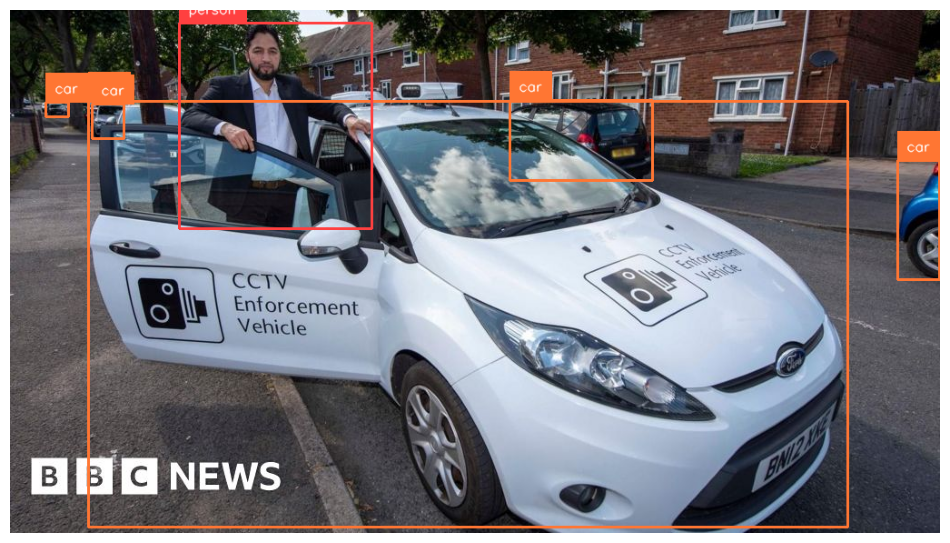

In [ ]:

model = get_model("rfdetr-large")

predictions = model.infer(image, confidence=0.5)[0]

detections = sv.Detections.from_inference(predictions)

labels = [prediction.class_name for prediction in predictions.predictions]

annotated_image = image.copy()
annotated_image = sv.BoxAnnotator().annotate(annotated_image, detections)
annotated_image = sv.LabelAnnotator().annotate(annotated_image, detections, labels)

sv.plot_image(annotated_image)

## VIDEO OBJECT DETECTION


In [ ]:
import supervision as sv
from rfdetr import RFDETRBase
from rfdetr.util.coco_classes import COCO_CLASSES
import cv2 # Import cv2

model = RFDETRBase()

def callback(frame, index):
    # Convert 4-channel frame to 3-channel if necessary
    if frame.shape[-1] == 4:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGRA2BGR)

    # Add .copy() after slicing to ensure a contiguous array with positive strides
    detections = model.predict(frame[:, :, ::-1].copy(), threshold=0.5)

    labels = [
        f"{COCO_CLASSES[class_id]} {confidence:.2f}"
        for class_id, confidence
        in zip(detections.class_id, detections.confidence)
    ]

    annotated_frame = frame.copy()
    annotated_frame = sv.BoxAnnotator().annotate(annotated_frame, detections)
    annotated_frame = sv.LabelAnnotator().annotate(annotated_frame, detections, labels)
    return annotated_frame

sv.process_video(
    source_path= "https://media.roboflow.com/supervision/video-examples/vehicles.mp4",
    target_path="/content/annotated_video.mp4",
    callback=callback
)

rf-detr-base.pth: 100%|██████████| 355M/355M [00:05<00:00, 67.9MiB/s]
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading pretrain weights


# SECTION 2: Object Counting

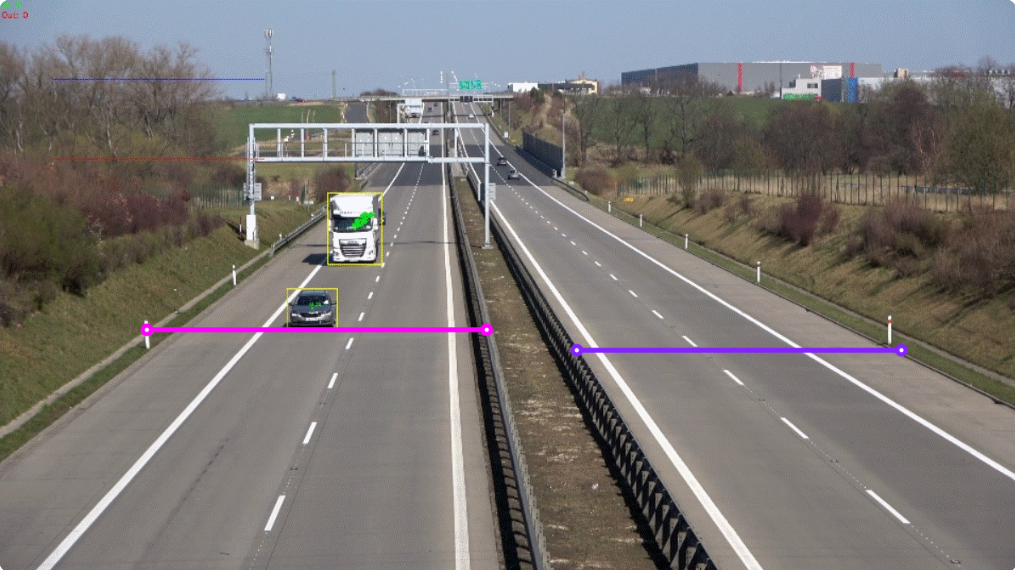

## ZONE ANALYTICS
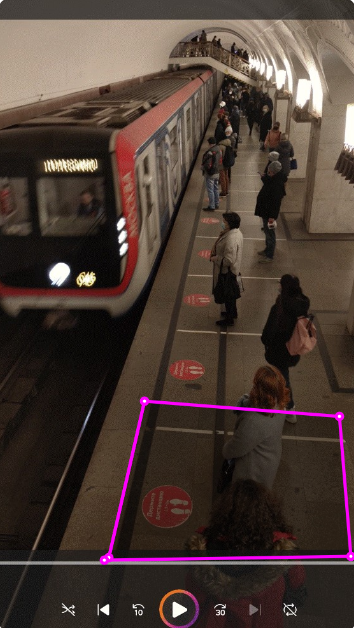

# SECTION 3: Heatmap Generation

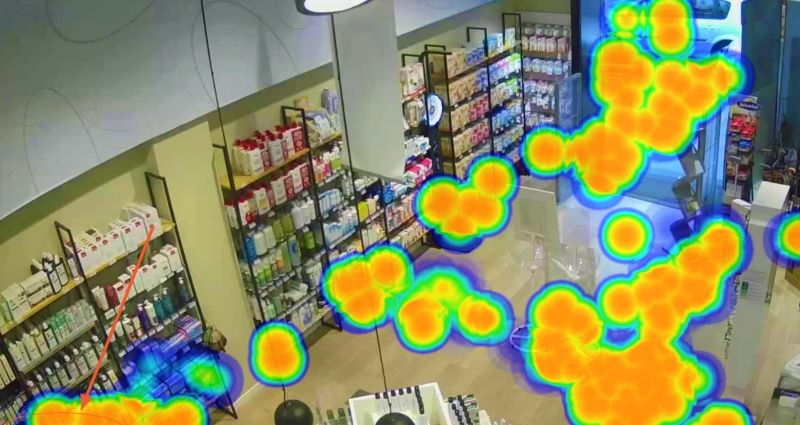

# SECTION 4: OCR (Text Extraction)

Detected Text:
The quick brown fox
jumped over the 5
lazy dogs!



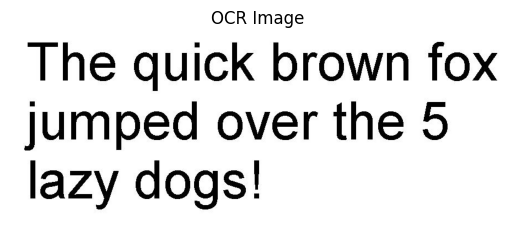

In [ ]:
import pytesseract
from PIL import Image
import cv2
import matplotlib.pyplot as plt

ocr_image = cv2.imread("/content/ocr.jpg")
ocr_image_rgb = cv2.cvtColor(ocr_image, cv2.COLOR_BGR2RGB)

# OCR
ocr_text = pytesseract.image_to_string(ocr_image_rgb)
print("Detected Text:")
print(ocr_text)

plt.imshow(ocr_image_rgb)
plt.title("OCR Image")
plt.axis(False)
plt.show()